# `build_dataset` Tutorial

This notebook shows how to use `build_dataset` — a factory function that automatically detects the data type of a Datamint project and returns the appropriate dataset class.

Instead of deciding upfront between `ImageDataset`, `VolumeDataset`, or `VideoDataset`, you just pass the project name and `build_dataset` figures it out.

**What you'll learn:**
1. Basic usage — load any project without knowing its data type
2. Inspecting what class was returned
3. Working with the dataset as usual
4. Handling mixed or unknown project types

## 1. Installation & Imports

In [ ]:
%pip install -U datamint --quiet

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datamint.dataset import build_dataset

/home/luan/Desktop/Datamint/Codes/datamint-python-api/datamint/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Basic Usage

`build_dataset` fetches a small sample of resources from your project, detects the data type, and returns the matching dataset — `ImageDataset`, `VolumeDataset`, or `VideoDataset`.

All keyword arguments are forwarded directly to the dataset constructor, so anything you'd pass to `ImageDataset(...)` or `VolumeDataset(...)` works here too.

In [3]:
PROJECT_NAME = "your-project-name"  # <-- Replace with your project name

ds = build_dataset(
    PROJECT_NAME,
    include_unannotated=True,
    allow_external_annotations=True,
)

print(ds)

ImageDataset
Dataset bccd_detection
    Number of datapoints: 364


## 3. Inspecting the Returned Dataset

`build_dataset` returns a fully instantiated dataset object. You can check exactly which class was selected and use all its methods normally.

In [4]:
print(f"Dataset type   : {type(ds).__name__}")
print(f"Number of items: {len(ds)}")
print(f"Segmentation labels: {ds.segmentation_labels_set}")
print(f"Image-level labels : {ds.image_labels_set}")

Dataset type   : VolumeDataset
Number of items: 20
Segmentation labels: []
Image-level labels : []


## 4. Working with the Dataset

The returned object behaves exactly like the underlying class. Indexing, iterating, slicing — everything works as documented in the individual dataset tutorials.

In [ ]:
item = ds[0]

img = item['image']
print(f"Image shape: {img.shape}")
print(f"Item keys  : {list(item.keys())}")

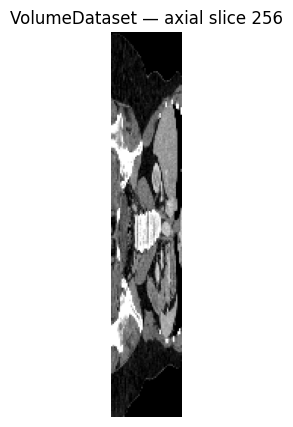

In [5]:
# Visualize the first item
# For 3D volumes (C, D, H, W), pick the middle slice; for 2D images (C, H, W), show directly
if img.ndim == 4:                  # volume: (C, D, H, W)
    mid = img.shape[1] // 2
    display_img = img[0, mid]
    title = f"{type(ds).__name__} — axial slice {mid}"
else:                              # image: (C, H, W)
    display_img = img[0]
    title = f"{type(ds).__name__} — item 0"

plt.figure(figsize=(5, 5))
plt.imshow(display_img, cmap='gray')
plt.title(title)
plt.axis('off')
plt.show()

## 5. Class-Specific Features Are Still Available

Because `build_dataset` returns the actual typed class (not a wrapper), you get full access to class-specific methods. For example, if the project contains 3D volumes, the returned `VolumeDataset` exposes `.slice()`.

In [6]:
from datamint.dataset import VolumeDataset

if isinstance(ds, VolumeDataset):
    sliced = ds.slice(axis='axial')
    print(f"Sliced dataset: {len(sliced)} axial slices")
    print(sliced[0]['image'].shape)  # (C, H, W)
else:
    print(f"Project contains {type(ds).__name__} data — .slice() not applicable.")

Some resources are not cached locally and will be downloaded during slicing. This may take time and bandwidth, especially for large volumes. Consider pre-caching resources if this is an issue.
Expanding to 'axial' slices: 100%|██████████| 12/12 [01:00<00:00,  5.01s/it]

Sliced dataset: 6144 axial slices
(1, 256, 47)
